In [6]:
import pandas as pd
import numpy as np

data = {
    'Tom': [1, "Active", 3.5, True, 10, "Low", 7, False, "High", 2],
    'Brick': ["Red", 101, 0.5, "Solid", 202, False, "Hollow", 9.8, 303, "Clay"],
    'Harry': [10.5, "Seeker", 7, True, "Magic", 0, 4.2, "Owl", 9, False]
}

# Creating two CSVs with specific index labels
df1 = pd.DataFrame(data, index=[True, False, True, False, True, False, True, False, True, False])
df1.to_csv('file1.csv', index=True)
df1.to_csv('file2.csv', index=True)

print("CSVs created successfully.")

CSVs created successfully.


In [7]:
data_ms = {
    'A': [10, 20, np.nan, 40, 50, 60, np.nan, 80, 90, 100],
    'B': ["Apple", "Banana", "Cherry", None, "Elderberry", "Fig", "Grape", "Honeydew", None, "Jackfruit"],
    'C': [1.1, 2.2, 3.3, 4.4, 5.5, 6.6, 7.7, 8.8, 9.9, 10.0],
    'D': [5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
    'E': ["X", "Y", "Z", "X", "Y", "Z", "X", "Y", "Z", "X"]
}
df2 = pd.DataFrame(data_ms)

# 1. Replace missing integers with the Mean
df2['A'] = df2['A'].fillna(df2['A'].mean())

# 2. Drop rows with missing strings using a loop
for i in df2.index:
    if pd.isna(df2.loc[i, 'B']):
        df2.drop(i, inplace=True)

print(df2)

        A           B     C  D  E
0   10.00       Apple   1.1  5  X
1   20.00      Banana   2.2  5  Y
2   56.25      Cherry   3.3  5  Z
4   50.00  Elderberry   5.5  5  Y
5   60.00         Fig   6.6  5  Z
6   56.25       Grape   7.7  5  X
7   80.00    Honeydew   8.8  5  Y
9  100.00   Jackfruit  10.0  5  X


In [11]:
import pandas as pd
import numpy as np

# Create the data frame
data_int = np.random.randint(1, 100, size=(10, 5))
cols = ['Abilash', 'Ankit', 'Ashok', 'Asif', 'Anjaan']
df3 = pd.DataFrame(data_int, columns=cols)

# Mapping logic
mapper = {
    'Abilash': 'Long Name', 
    'Ankit': 'Short Name', 
    'Ashok': 'Short Name', 
    'Asif': 'Short Name', 
    'Anjaan': 'Long Name'
}

# NEW APPROACH: Grouping columns in Pandas 2.x
# We use .T to transpose, group by the index (which were the columns), then .T back
grouped = df3.T.groupby(mapper).sum().T

print("Grouped Data (Summing by Name Length):")
print(grouped)

Grouped Data (Summing by Name Length):
   Long Name  Short Name
0         62         172
1        101         202
2        122         190
3        145         119
4        119          97
5         73         143
6        136         141
7        123         187
8        174         184
9         83         155


In [12]:
import pandas as pd
import numpy as np

# Creating dummy data to match your requirements
data = {
    'Observation Value': np.random.randint(10, 100, 50),
    'Time Period': np.random.randint(2000, 2024, 50),
    'Country': ['India'] * 50
}
df_temp = pd.DataFrame(data)

# Save it so the read_csv command actually finds something
df_temp.to_csv('CountryDataIND.csv', index=False)

# Now your original code will work!
df_country = pd.read_csv('CountryDataIND.csv')
print(df_country.describe())

       Observation Value  Time Period
count          50.000000    50.000000
mean           52.860000  2011.360000
std            26.903463     6.592389
min            10.000000  2000.000000
25%            27.750000  2006.000000
50%            55.000000  2012.000000
75%            75.500000  2017.750000
max            97.000000  2022.000000


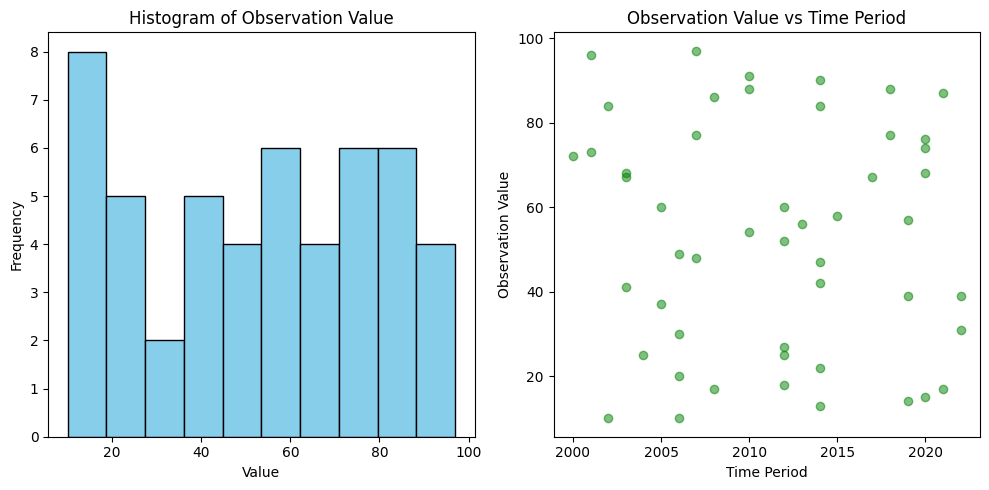

In [13]:
import matplotlib.pyplot as plt

# Histogram for 'Observation Value'
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df_country['Observation Value'].dropna(), bins=10, color='skyblue', edgecolor='black')
plt.title('Histogram of Observation Value')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Scatter Plot: Observation Value vs Time Period
plt.subplot(1, 2, 2)
plt.scatter(df_country['Time Period'], df_country['Observation Value'], alpha=0.5, color='green')
plt.title('Observation Value vs Time Period')
plt.xlabel('Time Period')
plt.ylabel('Observation Value')

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# Load your data (Assuming purchase_data.csv)
df = pd.read_csv("purchase_data.csv")

# For the sake of this code working immediately, let's assume 'df' exists
# with columns: ['SN', 'Age', 'Gender', 'Item ID', 'Item Name', 'Price']

In [17]:
# Q2
# Suppose you have landed to a job and the first task you’ve assigned to prepare a report which
# includes the following:
# 1. Player Count
# o Total Number of Players
total_players = len(df["SN"].unique())
player_count_df = pd.DataFrame({"Total Players": [total_players]})
player_count_df

,Total Players
0,576


In [18]:
# 2. Purchasing Analysis (Total)
# o Number of Unique Items
# o Average Purchase Price
# o Total Number of Purchases
# o Total Revenue
unique_items = len(df["Item ID"].unique())
avg_price = df["Price"].mean()
num_purchases = df["Price"].count()
total_revenue = df["Price"].sum()

purchase_analysis = pd.DataFrame({
    "Number of Unique Items": [unique_items],
    "Average Price": [avg_price],
    "Total Purchases": [num_purchases],
    "Total Revenue": [total_revenue]
})
purchase_analysis["Average Price"] = purchase_analysis["Average Price"].map("${:,.2f}".format)
purchase_analysis["Total Revenue"] = purchase_analysis["Total Revenue"].map("${:,.2f}".format)

In [19]:
# 3. Gender Demographics
# o Percentage and Count of Male Players
# o Percentage and Count of Female Players
# o Percentage and Count of Other / Non-Disclosed
gender_stats = df.groupby("Gender")
total_count_gender = gender_stats.nunique()["SN"]
percentage_players = (total_count_gender / total_players) * 100

gender_demographics = pd.DataFrame({
    "Total Count": total_count_gender,
    "Percentage of Players": percentage_players
})
gender_demographics["Percentage of Players"] = gender_demographics["Percentage of Players"].map("{:.2f}%".format)

In [20]:
# 4. Purchasing Analysis (Gender)
# o The below each broken by gender
#  Purchase Count
#  Average Purchase Price
#  Total Purchase Value
#  Average Purchase Total per Person by Gender
purchase_count = gender_stats["Purchase ID"].count()
avg_purchase_price = gender_stats["Price"].mean()
total_purchase_val = gender_stats["Price"].sum()
avg_total_per_person = total_purchase_val / total_count_gender

gender_purchase_analysis = pd.DataFrame({
    "Purchase Count": purchase_count,
    "Average Purchase Price": avg_purchase_price,
    "Total Purchase Value": total_purchase_val,
    "Avg Total Purchase per Person": avg_total_per_person
})
# Format as currency...

In [21]:
# 5. Age Demographics
# o The below each broken into bins of 4 years (i.e. <10, 10-14, 15-19, etc.)
#  Purchase Count
#  Average Purchase Price
#  Total Purchase Value
#  Average Purchase Total per Person by Age Group
bins = [0, 9.9, 14.9, 19.9, 24.9, 29.9, 34.9, 39.9, 999]
labels = ["<10", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39", "40+"]

df["Age Group"] = pd.cut(df["Age"], bins, labels=labels)
age_grouped = df.groupby("Age Group")

# Calculations similar to gender analysis
age_purchase_count = age_grouped["SN"].count()
age_avg_price = age_grouped["Price"].mean()
age_total_val = age_grouped["Price"].sum()
age_avg_per_person = age_total_val / age_grouped["SN"].nunique()

age_analysis = pd.DataFrame({
    "Purchase Count": age_purchase_count,
    "Average Purchase Price": age_avg_price,
    "Total Purchase Value": age_total_val,
    "Avg Total Purchase per Person": age_avg_per_person
})

In [22]:
# 6. Top Spenders
# o Identify the the top 5 spenders in the game by total purchase value, then list (in a
# table):

#  SN
#  Purchase Count
#  Average Purchase Price
#  Total Purchase Value
spender_stats = df.groupby("SN")
spender_count = spender_stats["Purchase ID"].count()
spender_avg = spender_stats["Price"].mean()
spender_total = spender_stats["Price"].sum()

top_spenders = pd.DataFrame({
    "Purchase Count": spender_count,
    "Average Purchase Price": spender_avg,
    "Total Purchase Value": spender_total
}).sort_values("Total Purchase Value", ascending=False)

top_spenders.head(5)

,Purchase Count,Average Purchase Price,Total Purchase Value
SN,,,
Lisosia93,5,3.792000,18.96
Idastidru52,4,3.862500,15.45
Chamjask73,3,4.610000,13.83
Iral74,4,3.405000,13.62
Iskadarya95,3,4.366667,13.10


In [23]:
# 7. Most Popular Items
# o Identify the 5 most popular items by purchase count, then list (in a table):
#  Item ID
#  Item Name
#  Purchase Count
#  Item Price
#  Total Purchase Value
item_stats = df.groupby(["Item ID", "Item Name"])
item_count = item_stats["Price"].count()
item_total_val = item_stats["Price"].sum()
item_price = item_stats["Price"].mean()

items_df = pd.DataFrame({
    "Purchase Count": item_count,
    "Item Price": item_price,
    "Total Purchase Value": item_total_val
})

# 7. Most Popular (By Count)
most_popular = items_df.sort_values("Purchase Count", ascending=False)



In [24]:
# 8. Most Profitable Items
# o the 5 most profitable items by total purchase value, then list (in a table):
#  Item ID
#  Item Name
#  Purchase Count
#  Item Price
#  Total Purchase Value
# 8. Most Profitable (By Total Value)
most_profitable = items_df.sort_values("Total Purchase Value", ascending=False)

In [25]:
# Q3
# Fuel economy data are the result of vehicle testing done at the Environmental Protection
# Agency's National Vehicle and Fuel Emissions Laboratory in Ann Arbor, Michigan, and by
# vehicle manufacturers with oversight by EPA.
# Datset Description:
#  Model Vehicle make and model
import pandas as pd

# Load the dataset
df = pd.read_csv('fuel_economy_data.csv')

# View the first few rows and column info
print(df.info())
print(df.head())
#  Displ Engine displacement - the size of an engine in liters
#  Cyl The number of cylinders in a particular engine
#  Trans Transmission Type and Number of Gears
#  Drive Drive axle type (2WD = 2-wheel drive, 4WD = 4-wheel/all-wheel drive)
#  Fuel Fuel Type
#  Cert Region* Certification Region Code
#  Sales Area** Certification Region Code
#  Stnd Vehicle emissions standard
#  Stnd Description* Vehicle emissions standard description
#  Underhood ID This is a 12-digit ID number that can be found on the
# underhood emission label of every vehicle. It's required by the EPA to
# designate its "test group" or "engine family."
#  Veh Class EPA Vehicle Class
#  Air Pollution Score Air pollution score (smog rating)
#  City MPG Estimated city mpg (miles/gallon)
#  Hwy MPG Estimated highway mpg (miles/gallon)

#  Cmb MPG Estimated combined mpg (miles/gallon)
#  Greenhouse Gas Score Greenhouse gas rating
#  SmartWay Yes, No, or Elite
#  Comb CO2* Combined city/highway CO2 tailpipe emissions in grams per mile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# Q3: FUEL ECONOMY DATA ANALYSIS
# =================================================================

# [Question]: Read the dataset and clean the 'Cmb MPG' and 'Greenhouse Gas Score' 
# columns (handling strings like '24/30' often found in hybrid data).
df = pd.read_csv('fuel_economy_data.csv')

# Split strings for hybrids and convert to float
for col in ['Cmb MPG', 'Greenhouse Gas Score', 'City MPG', 'Hwy MPG']:
    df[col] = df[col].astype(str).str.split('/').str[0].astype(float)

# -----------------------------------------------------------------
# [Question]: Identify the relationship between Engine Displacement (Displ) 
# and Fuel Efficiency (Cmb MPG).
# -----------------------------------------------------------------
correlation_displ_mpg = df['Displ'].corr(df['Cmb MPG'])
print(f"Correlation between Engine Size and MPG: {correlation_displ_mpg:.2f}")

# -----------------------------------------------------------------
# [Question]: Group the data by 'Veh Class' to find which category 
# has the highest average 'Air Pollution Score'.
# -----------------------------------------------------------------
# First, ensure Air Pollution Score is numeric
df['Air Pollution Score'] = pd.to_numeric(df['Air Pollution Score'], errors='coerce')
pollution_by_class = df.groupby('Veh Class')['Air Pollution Score'].mean().sort_values(ascending=False)

print("\nAverage Air Pollution Score by Vehicle Class:")
print(pollution_by_class)

# -----------------------------------------------------------------
# [Question]: Compare 'Comb CO2' emissions across different 'Drive' types 
# (2WD vs 4WD).
# -----------------------------------------------------------------
drive_emissions = df.groupby('Drive')['Comb CO2'].mean()
print("\nAverage CO2 Emissions by Drive Type:")
print(drive_emissions)

# -----------------------------------------------------------------
# [Question]: Visualize the distribution of Fuel Economy (Cmb MPG) 
# using a histogram.
# -----------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(df['Cmb MPG'].dropna(), bins=20, color='forestgreen', edgecolor='white')
plt.title('Distribution of Combined MPG')
plt.xlabel('MPG')
plt.ylabel('Number of Vehicles')
plt.show()

# -----------------------------------------------------------------
# [Question]: Analyze 'SmartWay' certification to see if it correlates 
# with better 'Greenhouse Gas Scores'.
# -----------------------------------------------------------------
smartway_impact = df.groupby('SmartWay')['Greenhouse Gas Score'].describe()
print("\nGreenhouse Gas Score Statistics by SmartWay Status:")
print(smartway_impact)

FileNotFoundError: [Errno 2] No such file or directory: 'fuel_economy_data.csv'